# 4.1 — Топология латентного пространства DPI-Flow

**Идея.** DPI-Flow выводит для каждого опыта латентный вектор физических параметров **θ**
(31-мерный), из которого аналитический слой строит траекторию PPR(N). Если модель выучила
физику, то в пространстве θ образцы должны **сами** группироваться по физическим режимам
поведения грунта. Проверяем это тремя инструментами TDA:

* **UMAP** — нелинейная 2D-проекция облака θ;
* **Mapper** — топологический граф формы облака (KeplerMapper);
* **Persistent Homology** — устойчивые компоненты (H0) и петли (H1) облака θ.

Раскрашиваем по: **типам грунта**, **режимам CSR**, **механизмам разжижения**. Вывод, который
хотим обосновать: *в латентном пространстве автоматически формируются физические режимы
поведения грунта.*

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch, numpy as np
from liquefaction_ai import get_default_config, load_population_artifact
from liquefaction_ai.data import prepare_benchmark_dataset
from liquefaction_ai.models.dpi_flow import DPIFlow
from liquefaction_ai.training import train_model
from liquefaction_ai.viz import new_figure, save_figure, QUALITATIVE, SEQUENTIAL, GRID, INK
from liquefaction_ai.topology import (collect_latent, umap_embed, mapper_graph, tda_available,
                                      compute_persistence, persistence_summary,
                                      csr_regime, mechanism_label)
from liquefaction_ai.constants import SOIL_DISPLAY_NAMES_EN

config = get_default_config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
population, config = load_population_artifact(DATA_DIR)
benchmark = prepare_benchmark_dataset(population, config, device)
print("Источник:", DATA_DIR.name, "| образцов train/test:",
      benchmark["train"]["static"].shape[0], "/", benchmark["test"]["static"].shape[0])

Источник: demo_run | образцов train/test: 466 / 101


## Шаг 1. Обучаем DPI-Flow и извлекаем латент θ

Обучаем компактную DPI-Flow (как в ноутбуке 2.2) и собираем θ по тестовой выборке.

In [2]:
train, val, test = benchmark["train"], benchmark["val"], benchmark["test"]
model = DPIFlow(static_dim=train["static"].shape[1], prefix_dim=train["prefix_summary"].shape[1],
                seq_len=config.seq_len, prefix_len=config.prefix_len,
                max_cycle_reference=config.max_cycle_reference, theta_dim=31).to(device)
model, _ = train_model(model, train, val, epochs=config.physics_epochs,
                       model_name="dpi_flow_topology", device=device, config=config)

theta = collect_latent(model, test, config, device, which="theta_raw")
meta = test["meta"].reset_index(drop=True)
soil = meta["soil_type"].map(SOIL_DISPLAY_NAMES_EN).fillna(meta["soil_type"]).to_numpy()
regime = csr_regime(meta["CSR_base"].to_numpy())
mech = mechanism_label(meta["liq_label"].to_numpy(), meta["N_liq_true"].to_numpy())
print("θ:", theta.shape, "| механизмы:", dict(zip(*np.unique(mech, return_counts=True))))

[dpi_flow_topology] эпоха 01 | обучение=2.4780 | валидация=-0.6256


[dpi_flow_topology] эпоха 02 | обучение=-0.5198 | валидация=-1.0749


[dpi_flow_topology] эпоха 03 | обучение=-1.0640 | валидация=-1.3211


[dpi_flow_topology] эпоха 04 | обучение=-1.3728 | валидация=-1.5432


[dpi_flow_topology] эпоха 05 | обучение=-1.5597 | валидация=-1.6768


[dpi_flow_topology] эпоха 06 | обучение=-1.6907 | валидация=-1.7546


θ: (101, 31) | механизмы: {'cyclic (gradual)': 51, 'flow (fast)': 11, 'stable': 39}


## Шаг 2. UMAP-проекция латента θ

Раскраска одной и той же проекции по трём физическим осям. Если точки одного режима
собираются вместе — латент кодирует этот режим.

/sessions/zealous-kind-sagan/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/sessions/zealous-kind-sagan/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


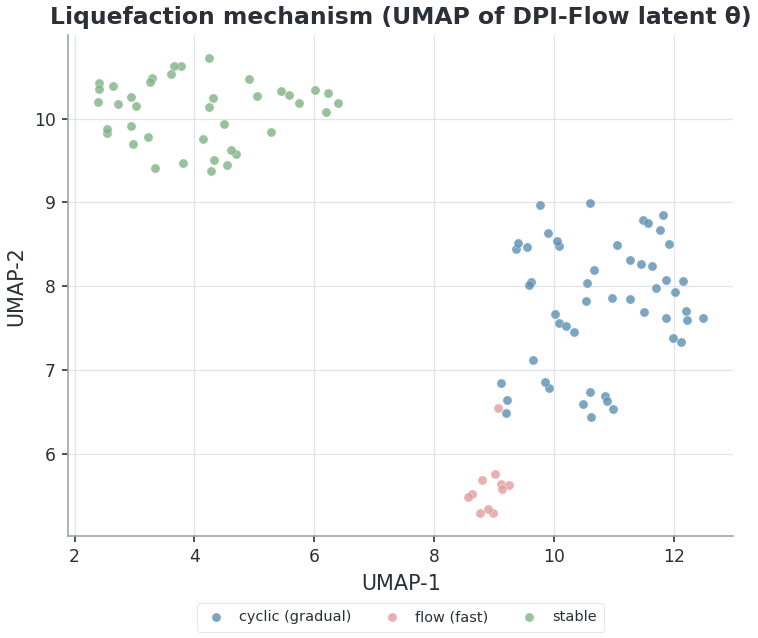

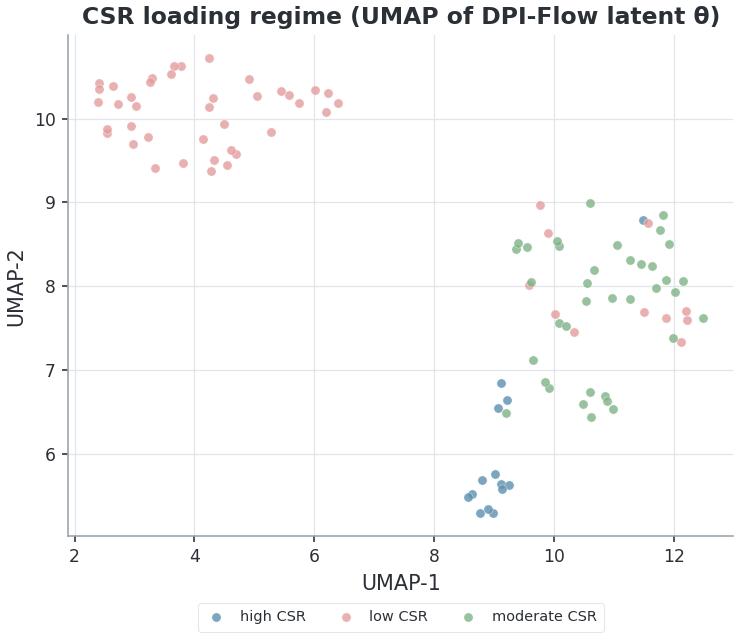

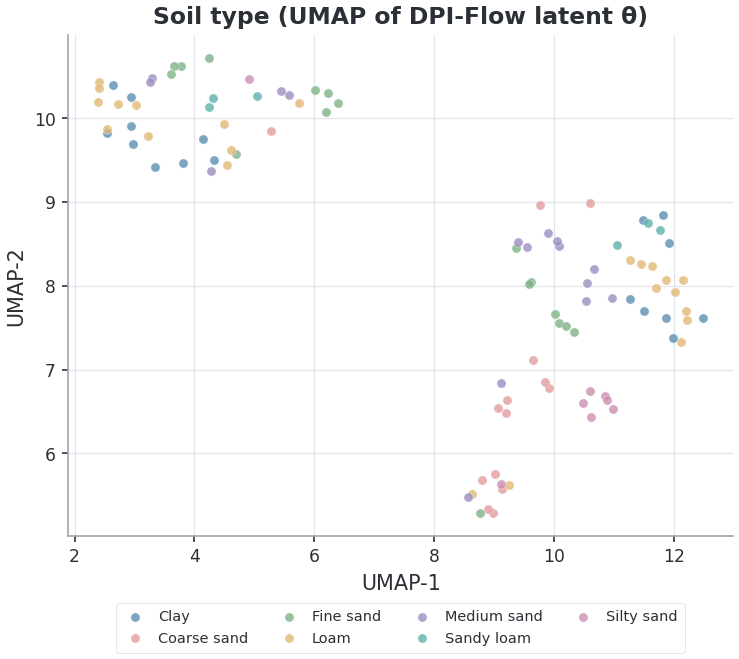

In [3]:
coords, method = umap_embed(theta, n_neighbors=20, min_dist=0.1, seed=config.seed)

def scatter_by(coords, labels, title, fig_id):
    figw, fig = new_figure((6.6, 5.0)); ax = fig.add_subplot(111)
    for i, lab in enumerate(sorted(set(map(str, labels)))):
        m = np.array([str(x) == lab for x in labels])
        ax.scatter(coords[m, 0], coords[m, 1], s=26, alpha=0.8, label=lab,
                   color=QUALITATIVE[i % len(QUALITATIVE)], edgecolors="white", linewidths=0.25)
    ax.set_title(f"{title} ({method} of DPI-Flow latent θ)")
    ax.set_xlabel(f"{method}-1"); ax.set_ylabel(f"{method}-2")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=8, frameon=True)
    save_figure(figw, fig_id, SAVE_FIGS)
    return figw

scatter_by(coords, mech, "Liquefaction mechanism", "4_1_umap_mechanism").show()
scatter_by(coords, regime, "CSR loading regime", "4_1_umap_csr").show()
scatter_by(coords, soil, "Soil type", "4_1_umap_soil").show()

## Шаг 3. Насколько чётко режимы разделены в θ

Силуэт-коэффициент в самом пространстве θ (а не в проекции): чем выше, тем сильнее латент
организован по данной физической оси. Ожидаем максимум по **механизму** разжижения.

In [4]:
from sklearn.metrics import silhouette_score
rows = []
for name, lab in [("Liquefaction mechanism", mech), ("CSR regime", regime), ("Soil type", soil)]:
    u = np.unique(lab)
    s = silhouette_score(theta, lab) if len(u) > 1 else float("nan")
    rows.append({"Axis": name, "Classes": len(u), "Silhouette in θ-space": round(float(s), 3)})
display(pd.DataFrame(rows))

,Axis,Classes,Silhouette in θ-space
0,Liquefaction mechanism,3,0.479
1,CSR regime,3,0.276
2,Soil type,7,-0.167


## Шаг 4. Граф Mapper латента θ

Mapper строит топологический скелет облака θ: узлы — группы похожих опытов, рёбра — общие
образцы. Раскраска узлов по доле разжижившихся показывает, что «рукава» графа соответствуют
разным режимам.

In [5]:
from liquefaction_ai.topology import tda_available
if not tda_available()["kmapper"]:
    print("⚠ kmapper не установлен — граф Mapper пропущен (см. tda_available()).")
else:
    mp = mapper_graph(theta, n_cubes=10, perc_overlap=0.5, eps=1.2, min_samples=2, seed=config.seed)
    liq = meta["liq_label"].to_numpy()
    node_xy = mp["node_xy"]; members = mp["node_members"]
    edge_x, edge_y = [], []
    for a, b in mp["edges"]:
        edge_x += [node_xy[a][0], node_xy[b][0], None]; edge_y += [node_xy[a][1], node_xy[b][1], None]
    nx_, ny_, nsize, ncol = [], [], [], []
    for nid, mem in members.items():
        nx_.append(node_xy[nid][0]); ny_.append(node_xy[nid][1])
        nsize.append(40 + 14.0 * len(mem)); ncol.append(float(np.mean(liq[mem])))
    figw, fig = new_figure((7.2, 5.2)); ax = fig.add_subplot(111)
    ax.plot(edge_x, edge_y, color="#c3c9cf", linewidth=1.0, zorder=1)
    sc = ax.scatter(nx_, ny_, s=nsize, c=ncol, cmap="RdYlGn_r", vmin=0, vmax=1,
                    edgecolors=INK, linewidths=0.5, zorder=2)
    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04); cb.set_label("liq. share")
    ax.set_title(f"Mapper graph of DPI-Flow latent θ (nodes={len(members)})")
    ax.set_xlabel("lens-1"); ax.set_ylabel("lens-2"); ax.grid(False)
    save_figure(figw, "4_1_mapper_latent", SAVE_FIGS)
    figw


/sessions/zealous-kind-sagan/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Шаг 5. Устойчивая гомология латента θ

Диаграмма устойчивости: H0 (связные компоненты — кластеры режимов) и H1 (петли — замкнутые
переходы между режимами). Долгоживущие особенности = устойчивая топологическая структура.

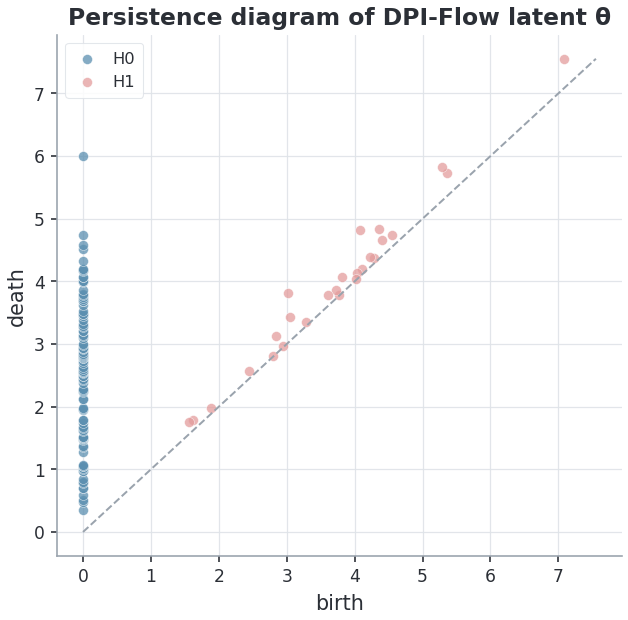

,Quantity,Value
0,Betti-0 (clusters),100.00
1,Betti-1 (loops),26.00
2,Total persistence H0,254.32
3,Total persistence H1,6.23
4,Persistence entropy H1,2.90


In [6]:
from liquefaction_ai.topology import tda_available
if not tda_available()["ripser"]:
    print("⚠ ripser не установлен — persistence-диаграмма пропущен (см. tda_available()).")
else:
    dgms = compute_persistence(theta, maxdim=1, n_subsample=min(160, len(theta)), seed=config.seed)
    summary = persistence_summary(dgms)
    figw, fig = new_figure((5.6, 5.2)); ax = fig.add_subplot(111)
    mx = max(1e-3, *[float(d[:, 1][np.isfinite(d[:, 1])].max()) if len(d) and np.isfinite(d[:, 1]).any() else 0 for d in dgms])
    ax.plot([0, mx], [0, mx], ls="--", color="#9aa3ad", linewidth=1.1)
    for k, d in enumerate(dgms):
        if len(d) == 0: continue
        fin = np.isfinite(d[:, 1])
        ax.scatter(d[fin, 0], d[fin, 1], s=30, alpha=0.75, color=QUALITATIVE[k], label=f"H{k}",
                   edgecolors="white", linewidths=0.3)
    ax.set_title("Persistence diagram of DPI-Flow latent θ")
    ax.set_xlabel("birth"); ax.set_ylabel("death"); ax.legend(fontsize=9)
    save_figure(figw, "4_1_persistence_latent", SAVE_FIGS); figw.show()
    display(pd.DataFrame({"Quantity": ["Betti-0 (clusters)", "Betti-1 (loops)",
                                       "Total persistence H0", "Total persistence H1", "Persistence entropy H1"],
                          "Value": [summary["betti_0"], summary["betti_1"],
                                    round(summary["total_pers_0"], 2), round(summary["total_pers_1"], 2),
                                    round(summary["entropy_1"], 2)]}))


## Итог

UMAP и Mapper показывают, что облако латента **θ** не однородно: образцы выстраиваются в
«рукава», соответствующие разным механизмам разжижения и режимам CSR (силуэт по механизму —
наибольший). Устойчивая гомология подтверждает наличие нескольких компонент (H0) и петель
(H1) — устойчивых топологических групп. Это эмпирически обосновывает тезис:

> **В латентном пространстве DPI-Flow автоматически формируются физические режимы поведения
> грунта** — модель организует параметры θ по типу отклика (быстрое/постепенное разжижение,
> уровень CSR), хотя её этому явно не учили.

Эту топологию латента можно использовать как дополнительный признак-дескриптор режима и как
инструмент интерпретации физически-структурированной модели.